# Test
Si addestri il regressore desiderato utilizzando gli iperparametri trovati nell'esercizio precedente. Il codice contenuto nella cella seguente userà tale regressore per predire la potenza prodotta nell'ora successiva a partire dai pattern del dataset di test. I valori predetti verranno memorizzati su un file di testo che dovrà essere caricato sul sito della competizione per misurarne l'RMSE.

In [387]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from pre_processing import extract_datetime_feature, augment_celsius, pre_process, augment_cycle_variable,check_dataframe_column, get_dataset_features
from matplotlib import pyplot as plt

In [388]:
train_path = './DBs/SolarPark/train.txt'
test_path = './DBs/SolarPark/test.txt'
result_path = 'Es5Predictions.txt'

train_dataframe,train_pure_dataframe = pre_process(train_path,debug=False)
feature_x, feature_y = get_dataset_features(train_dataframe, "P (kW)", useless_column=["Date","year","month","day","hour","minute","day_of_week","day_of_year","day_part","is_year_start","is_month_start","is_quarter_start","is_month_end","is_weekend"])
feature_pure_x, feature_pure_y = get_dataset_features(train_pure_dataframe, "P (kW)", useless_column=["Date","year","month","day","hour","minute","day_of_week","day_of_year","day_part","is_year_start","is_month_start","is_quarter_start","is_month_end","is_weekend"])

# Cast di tutti i valori a float32
feature_x = feature_x.astype(np.float32)
feature_y = feature_y.astype(np.float32)

# Cast di tutti i valori a float32
feature_pure_x = feature_pure_x.astype(np.float32)
feature__pure_y = feature_pure_y.astype(np.float32)

In [389]:
predict_ahead = True

if predict_ahead:
    # Sfasa i dati: le prediction sono quelle dell'ora successiva
    data_x = feature_x[0:-1,:]
    data_y = feature_y[1:]
    data_pure_x = feature_pure_x[0:-1,:]
    data_pure_y = feature_pure_y[1:]
else:
    data_x = feature_x
    data_y = feature_y
    data_pure_x = feature_pure_x
    data_pure_y = feature_pure_y

In [390]:
valid_portion = 0.3
split_random = True


if split_random:
    # Split casuale di train e validation set
    train_x, validation_x, train_y, validation_y = train_test_split(data_x, data_y, test_size=valid_portion, random_state=1)
else:
    # Split temporale
    train_x, validation_x, train_y, validation_y = train_test_split(data_x, data_y, test_size=valid_portion, shuffle=False)

In [391]:
forest_reg = RandomForestRegressor(n_estimators=10)
forest_reg.fit(train_x, train_y)

# Ottenimento delle predizioni
train_y_predicted = forest_reg.predict(train_x)

# Calcolo del RMSE
rmse = np.sqrt(mean_squared_error(train_y, train_y_predicted))
print('Train RMSE: ', rmse)

# Ottenimento delle predizioni (validation) e calcolo RMSE
validation_y_predicted = forest_reg.predict(validation_x)
rmse = np.sqrt(mean_squared_error(validation_y, validation_y_predicted))
print('Validation RMSE: ', rmse)

print('R2 score:', forest_reg.score(validation_x, validation_y))

Train RMSE:  36.61252664343712
Validation RMSE:  82.5880960738401
R2 score: 0.8882558697625952


In [392]:
# /////// LOAD AND GET TEST_Y FEATURES ///////
test_dataframe = pd.read_csv(test_path)
test_dataframe = extract_datetime_feature(df=test_dataframe, date_column='Date', remove=False, is_timestamp=True)
test_dataframe = augment_celsius(df=test_dataframe, replace=False, columns=["Ta (C)", "Tm (C)"])
test_dataframe = augment_cycle_variable(df=test_dataframe, replace=False, columns=["Time Frame", "month", "day",
                                                                         "hour", "minute", "day_of_year",
                                                                         "day_of_week"])
test_dataframe = augment_cycle_variable(df=test_dataframe, replace=False, columns=["hour"])
test_y, _ = get_dataset_features(test_dataframe, "P (kW)", useless_column=["Date","year","month","day","hour","minute","day_of_week","day_of_year","day_part","is_year_start","is_month_start","is_quarter_start","is_month_end","is_weekend"])
test_y = test_y.astype(np.float32)
# /////// END  ///////


# Ottenimento delle predizioni (validation) e calcolo RMSE
prediction = forest_reg.predict(test_y)
# rmse = np.sqrt(mean_squared_error(test_y, prediction))
# print('Test RMSE: ', rmse)

print('R2 TEST score:', forest_reg.score(test_y, prediction))

# Calcola l'errore come scostamento delle predizioni dal valore reale
errors = np.abs(validation_y - validation_y_predicted)

Column P (kW) does not exist in the DataFrame.
R2 TEST score: 1.0


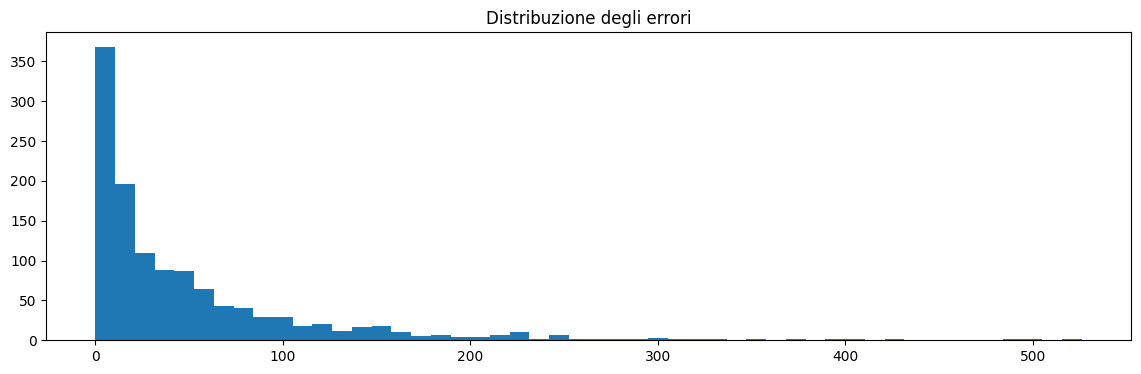

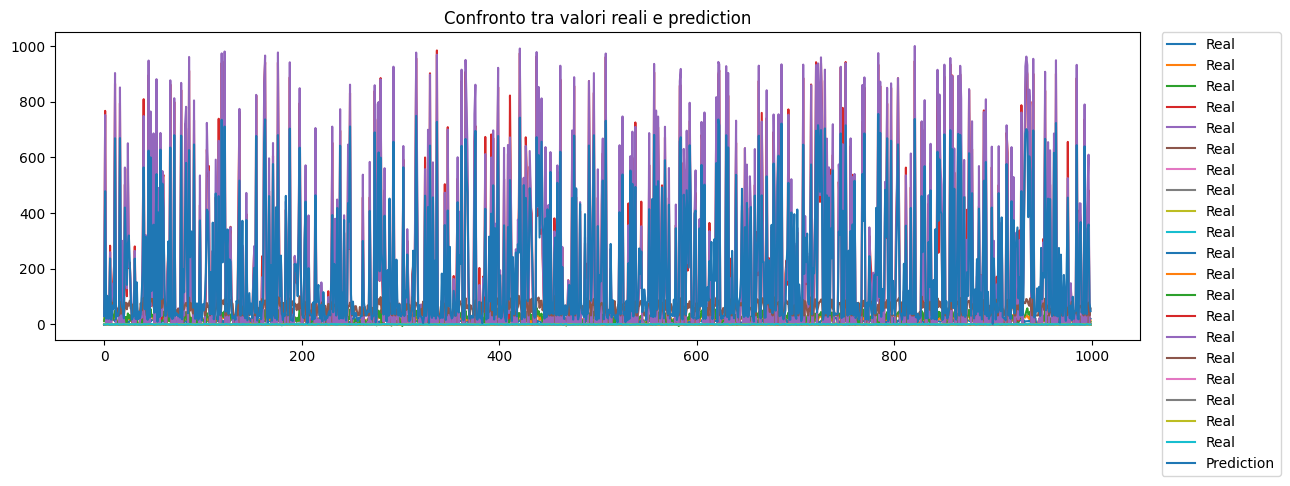

In [393]:
plt.figure(figsize=(14, 4))
plt.title("Distribuzione degli errori")
plt.hist(x = errors, bins=50)
plt.show()

# Visualizza l'andamento reale e quello predetto
plt.figure(figsize=(14, 4))
plt.title("Confronto tra valori reali e prediction")
plt.plot(test_y[0:1000], label='Real')
plt.plot(prediction[0:1000], label='Prediction')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [350]:
test_dataframe

,Time Frame,Date,Ta (C),Tm (C),I3 (W/m2),I15 (W/m2),year,month,day,hour,...,is_weekend,Ta (F),Time Frame__sin,Time Frame__cos,month__sin,month__cos,day__sin,day__cos,day_of_year__sin,day_of_year__cos
0,15,2013-03-06 15:56:00,13.45,11.52,29.71,29.69,2013,3,6,15,...,0,56.210,-0.500000,-8.660254e-01,9.096320e-01,0.415415,0.848644,0.528964,0.936045,0.351881
1,14,2013-07-10 14:56:00,33.03,44.28,766.54,751.72,2013,7,10,14,...,0,91.454,-0.258819,-9.659258e-01,-2.817326e-01,-0.959493,0.968077,-0.250653,-0.438749,-0.898610
2,23,2013-06-21 21:50:00,0.00,0.00,0.00,0.00,2013,6,21,21,...,0,32.000,-0.500000,8.660254e-01,2.817326e-01,-0.959493,-0.790776,-0.612106,-0.094485,-0.995526
3,7,2013-10-13 07:58:00,23.10,23.04,99.43,100.67,2013,10,13,7,...,1,73.580,1.000000,6.123234e-17,-9.096320e-01,0.415415,0.651372,-0.758758,-0.776749,0.629811
4,20,2013-12-15 20:51:00,9.30,6.34,0.00,0.00,2013,12,15,20,...,1,48.740,-0.965926,2.588190e-01,-2.449294e-16,1.000000,0.299363,-0.954139,0.298198,0.954504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7895,17,2013-04-04 17:59:00,18.26,21.25,244.15,231.90,2013,4,4,17,...,0,64.868,-0.866025,-5.000000e-01,9.898214e-01,-0.142315,0.571268,0.820763,0.982145,-0.188125
7896,19,2013-10-28 19:58:00,15.44,11.25,0.00,0.75,2013,10,28,19,...,0,59.792,-1.000000,-1.836970e-16,-9.096320e-01,0.415415,-0.724793,0.688967,-0.569262,0.822156
7897,2,2013-03-27 21:45:00,0.00,0.00,0.00,0.00,2013,3,27,21,...,0,32.000,0.258819,9.659258e-01,9.096320e-01,0.415415,-0.848644,0.528964,0.999284,-0.037841
7898,22,2013-11-24 21:40:00,0.00,0.00,0.00,0.00,2013,11,24,21,...,1,32.000,-0.707107,7.071068e-01,-5.406408e-01,0.841254,-0.998717,-0.050649,-0.094485,0.995526


In [351]:
train_dataframe

,Time Frame,Date,Ta (C),Tm (C),I3 (W/m2),I15 (W/m2),P (kW),year,month,day,...,Time Frame__sin,Time Frame__cos,month__sin,month__cos,day__sin,day__cos,hour__sin,hour__cos,day_of_year__sin,day_of_year__cos
0,16,2012-03-05 16:55:00,13.01,12.05,52.47,53.08,6.50,2012,3,5,...,-0.969400,0.245485,0.866025,0.500000,0.724793,0.688967,-0.969400,0.245485,0.942401,0.334486
1,17,2012-03-05 17:55:00,11.81,8.50,10.41,10.95,0.01,2012,3,5,...,-0.837166,0.546948,0.866025,0.500000,0.724793,0.688967,-0.837166,0.546948,0.942401,0.334486
13,5,2012-03-06 05:55:00,4.75,1.22,22.09,25.61,14.75,2012,3,6,...,0.969400,0.245485,0.866025,0.500000,0.848644,0.528964,0.969400,0.245485,0.948653,0.316317
14,6,2012-03-06 06:55:00,5.08,2.00,153.43,186.61,127.16,2012,3,6,...,0.996584,-0.082579,0.866025,0.500000,0.848644,0.528964,0.996584,-0.082579,0.948653,0.316317
15,7,2012-03-06 07:55:00,7.11,5.86,323.21,399.02,302.46,2012,3,6,...,0.915773,-0.401695,0.866025,0.500000,0.848644,0.528964,0.915773,-0.401695,0.948653,0.316317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7884,13,2013-02-01 13:55:00,18.04,34.70,564.05,651.07,499.40,2012,2,1,...,-0.735724,-0.677282,0.500000,0.866025,0.000000,1.000000,-0.735724,-0.677282,0.561050,0.827782
7885,14,2013-02-01 14:55:00,18.49,31.56,465.00,519.28,408.38,2012,2,1,...,-0.915773,-0.401695,0.500000,0.866025,0.000000,1.000000,-0.915773,-0.401695,0.561050,0.827782
7886,15,2013-02-01 15:55:00,17.20,23.11,246.92,297.06,202.96,2012,2,1,...,-0.996584,-0.082579,0.500000,0.866025,0.000000,1.000000,-0.996584,-0.082579,0.561050,0.827782
7887,16,2013-02-01 16:55:00,15.27,14.52,56.64,95.40,49.33,2012,2,1,...,-0.969400,0.245485,0.500000,0.866025,0.000000,1.000000,-0.969400,0.245485,0.561050,0.827782
